## Figures Appendix B - Synthetic examples

In [42]:
# env: notebook
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import random

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import LinearLocator

from tensorly.decomposition import parafac

import torch

from funtd import FTD, P1DesignMatrix

In [26]:
%load_ext autoreload
%autoreload 2

In [27]:
def symm_cmap_and_norm(values):
    colors = ['#084594', 'white', '#cb181d']
    cmap = LinearSegmentedColormap.from_list("blue_white_red", colors, N=256)

    # Define symmetric normalization (centered at 0)
    vmin, vcenter, vmax = values.min(), 0, values.max()
    vmax_abs = max(abs(vmin), abs(vmax))  # makes color intensity symmetric
    norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0, vmax=vmax_abs)

    return cmap, norm

### Synthetic spatial and temporal functions

In [28]:
os.makedirs(f"./Results_synthetic", exist_ok=True)

x = np.linspace(0., 2., 51)
t = np.linspace(0., 1., 21)

In [29]:
def f_floor(x):
    return np.floor(x)

def f_ceil(x):
    return np.ceil(x)

def f_quad(x):
    return x**2

def f_cubic(x):
    return x**3

def g_sin(t):
    return np.sin(np.pi * t)

def g_gauss(t):
    # Gaussian-like peak at t=0.5
    value = np.exp(-((t - 0.5) ** 2) / 0.01)
    return value

def g_lin(t):
    return t

In [30]:
random.seed(1234)
np.random.seed(1234)

n_vol = 30
age    = [random.uniform(20, 60) for _ in range(n_vol)]
weight = [random.uniform(60, 80) for _ in range(n_vol)]
height = [random.uniform(1.5, 1.75) for _ in range(n_vol)]
# groupe = [random.randint(0,2) for _ in range(n_vol)]

P_list = []
for i in range(n_vol):
    # P = np.array([((age[i]+weight[i]) * f_quad(x) * g_sin(t) + bmi[i] * f_floor(x) * g_gauss(t)) for t in t])
    P = np.array([((age[i]/np.max(age)) * f_quad(x) * g_sin(t) + weight[i]/np.max(weight) * f_ceil(x) * g_gauss(t)) for t in t])

    # if groupe[i] == 0:
    #     P = np.array([((age[i]/np.max(age)) * f_quad(x) * g_sin(t) + weight[i]/np.max(weight) * f_ceil(x) * g_gauss(t)) for t in t])
    # elif groupe[i] == 1:
    #     P = np.array([((age[i]/np.max(age))**2 * f_quad(x) * g_sin(t) + weight[i]/np.max(weight) * f_ceil(x) * g_gauss(t)) for t in t])
    # elif groupe[i] == 2:
    #     P = np.array([(((age[i]-40)/(np.max(age)-40))**2 * f_quad(x) * g_sin(t) + weight[i]/np.max(weight) * f_ceil(x) * g_gauss(t)) for t in t])
    
    P_list.append(P)

n_t   = len(t)
n_p   = len(x)

P_3d  = np.stack(P_list, axis=0)

## Add measurement noise
# Noise level %
SNR_objective = 15

# Generate standard normal noise
noise_tensor = np.random.randn(*P_3d.shape)

# Apply SNR per volunteer
scaled_noise = np.zeros_like(P_3d)
for i in range(n_vol):
    signal_i_power  = np.mean(P_3d[i]**2)
    scaled_noise[i] = noise_tensor[i] * np.sqrt(signal_i_power / SNR_objective)

signal_power = np.mean(P_3d**2)
noise_power  = np.mean(scaled_noise**2) # equivalent to np.var(scaled_noise) since the noise is zero-mean
SNR = signal_power / noise_power
print(f"Signal-to-Noise Ratio (SNR): {SNR:.2f}")

# Create the final noisy observation
P_3d = P_3d + scaled_noise

P_3d = np.transpose(P_3d, (2, 1, 0))
print(f"Tensor shape: {P_3d.shape}")

Signal-to-Noise Ratio (SNR): 15.06
Tensor shape: (51, 21, 30)


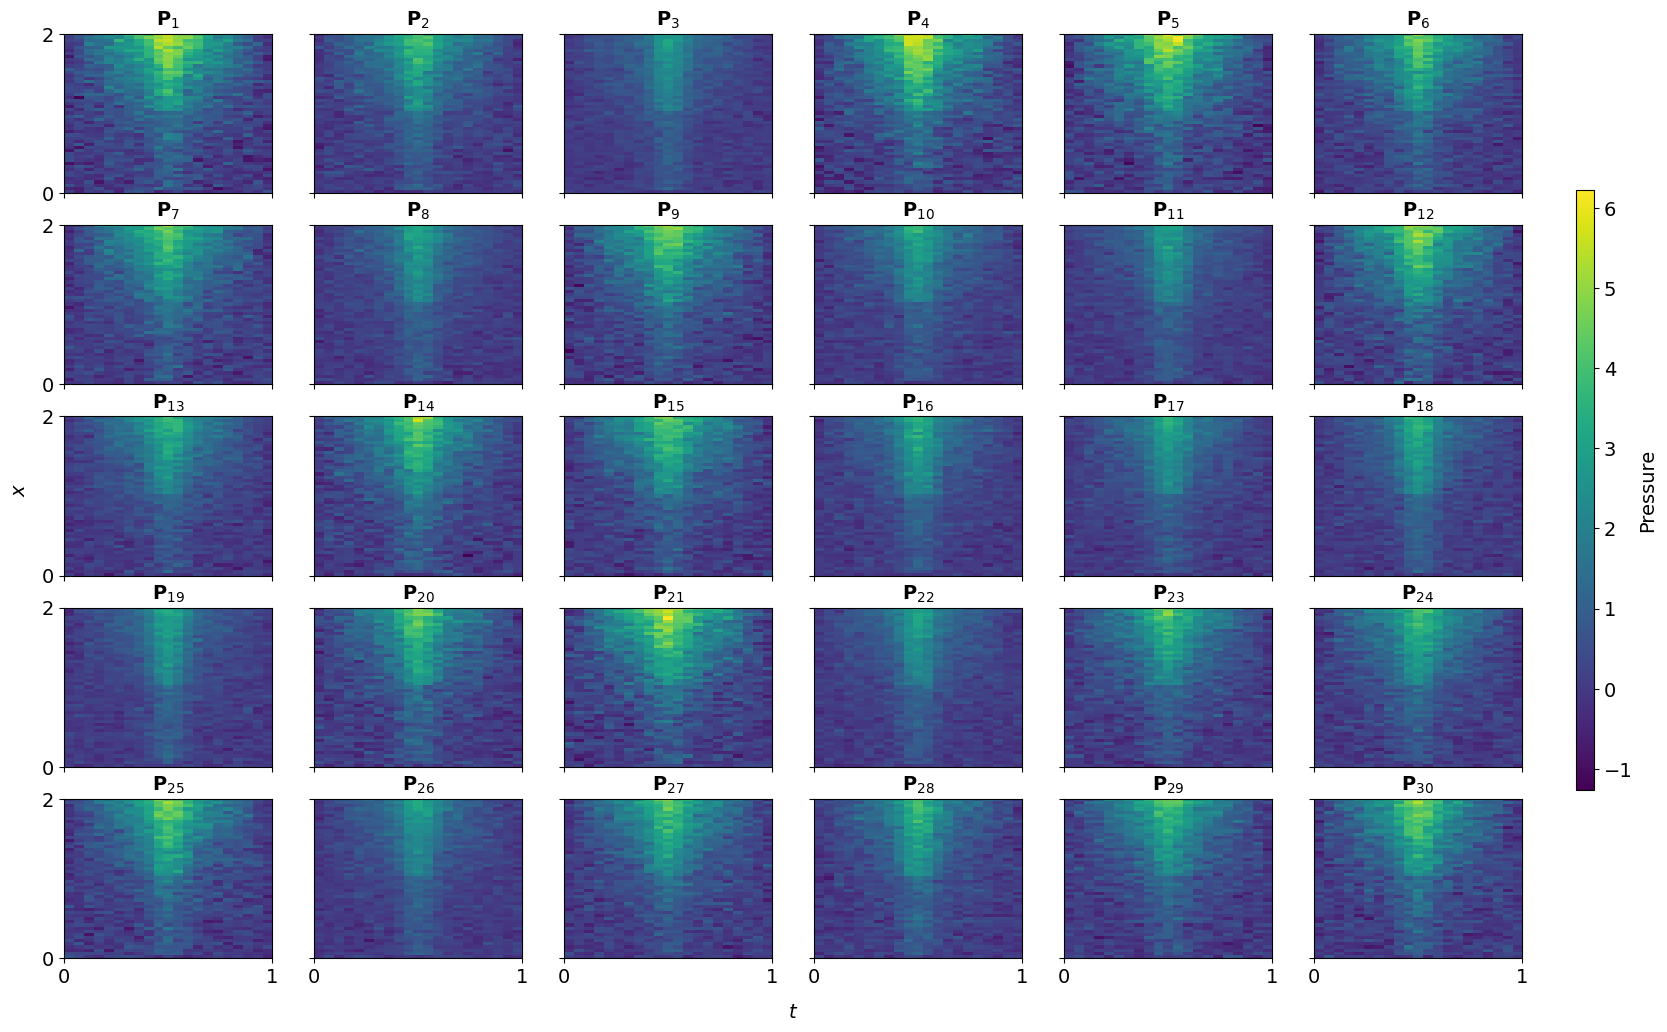

In [31]:
# Figure with synthetic fields
font_size = 14

ncols = 6
nrows = math.ceil(n_vol / ncols)

vmin = np.min(P_3d)
vmax = np.max(P_3d)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_vol):
    field_2d = P_3d[:, :, i]
    
    im = axes[i].imshow(
        field_2d,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        extent=[np.min(t), np.max(t), np.min(x), np.max(x)]
    )
    
    axes[i].set_title(rf'$\mathbf{{P}}_{{ {i+1} }}$', fontsize=font_size)

    axes[i].xaxis.set_major_locator(LinearLocator(2))
    axes[i].yaxis.set_major_locator(LinearLocator(2))

    axes[i].tick_params(axis='both', which='major', labelsize=font_size)

for j in range(n_vol, len(axes)):
    axes[j].axis('off')

left_margin = 0.07
right_margin = 0.88
fig.subplots_adjust(left=left_margin, right=right_margin) # wspace=0.35, hspace=0.4

cbar_ax = fig.add_axes([0.91, 0.25, 0.01, 0.5]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)

cbar.set_label('Pressure', size=font_size)
cbar.ax.tick_params(labelsize=font_size)

center_x = (left_margin + right_margin) / 2.0

fig.text(center_x, 0.06, r'$t$', ha='center', fontsize=font_size)
fig.text(0.04, 0.5, r'$x$', va='center', rotation='vertical', fontsize=font_size)
plt.savefig(f"Results_synthetic/synthetic_fields.pdf", bbox_inches='tight')
plt.show()

### CP decomposition

In [32]:
CP_rank = 2

weights, factors = parafac(P_3d, rank=CP_rank, n_iter_max=200, verbose=False) # parafac (CP) decomposition
spatial_CP = factors[0] # n_p   x n_modes
temp_CP    = factors[1] # n_t   x n_modes
pat_CP     = factors[2] # n_vol x n_modes

In [33]:
assert set(weights) == {1}

norm_spatial = np.linalg.norm(spatial_CP, axis=0, keepdims=True)
norm_pat     = np.linalg.norm(pat_CP, axis=0, keepdims=True)

norm_spatial_CP = spatial_CP / norm_spatial
renorm_temp_CP  = temp_CP * norm_spatial * norm_pat
norm_pat_CP     = pat_CP / norm_pat

# Calculate the norm of each column
col_norms = np.linalg.norm(renorm_temp_CP, axis=0)

# Get the indices that would sort the norms in descending order
sorted_indices = np.argsort(-col_norms)

# Reorder the columns of all three matrices
norm_spatial_CP = norm_spatial_CP[:, sorted_indices]
renorm_temp_CP  = renorm_temp_CP[:, sorted_indices]
norm_pat_CP     = norm_pat_CP[:, sorted_indices]

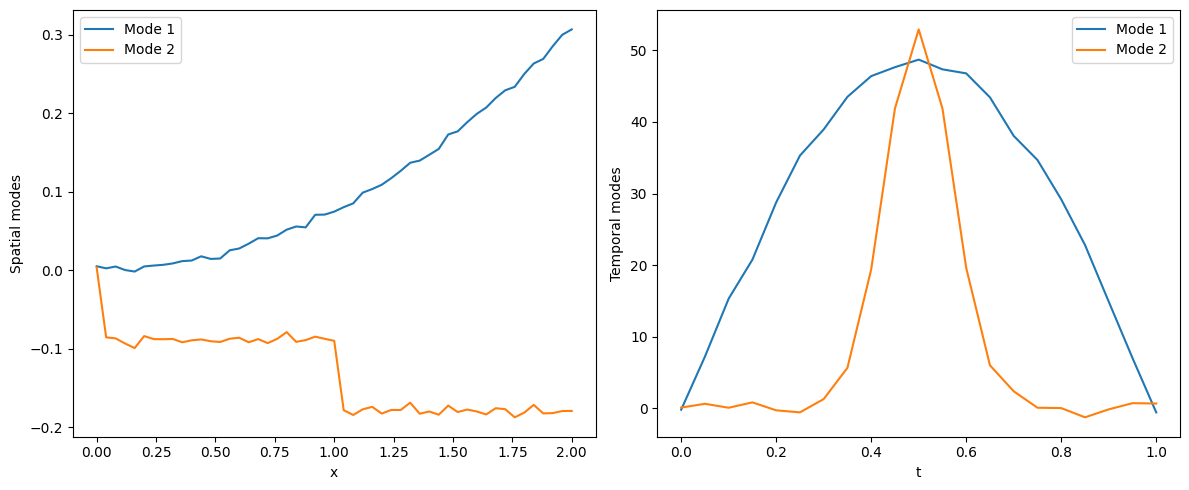

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Spatial modes
for r in range(CP_rank):
    axs[0].plot(x, norm_spatial_CP[:,r], label=f'Mode {r+1}')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Spatial modes')
axs[0].legend()

# Temporal modes
for r in range(CP_rank):
    axs[1].plot(t, renorm_temp_CP[:,r], label=f'Mode {r+1}')
axs[1].set_xlabel('t')
axs[1].set_ylabel('Temporal modes')
axs[1].legend()

plt.tight_layout()
plt.show()

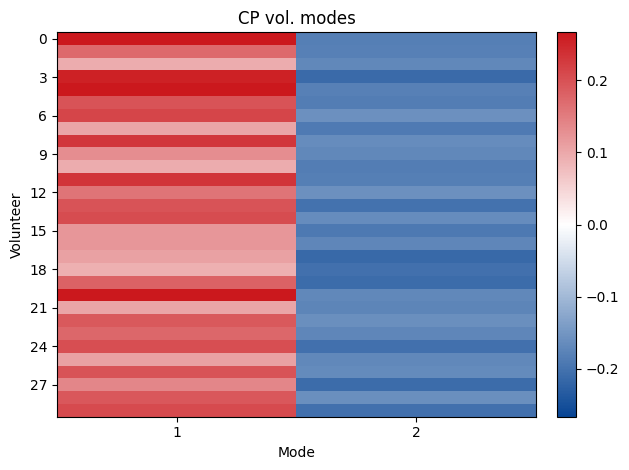

In [35]:
plt.figure()

cmap, norm = symm_cmap_and_norm(norm_pat_CP)

im = plt.imshow(norm_pat_CP, aspect='auto', cmap=cmap, interpolation='nearest', norm=norm)

plt.title(rf'CP vol. modes')
plt.xlabel('Mode')
plt.ylabel('Volunteer')

plt.yticks(range(n_vol))#, [f"Vol {vol}" for vol in reduced_model.keys()])
plt.xticks(range(norm_pat_CP.shape[1]), labels=range(1, norm_pat_CP.shape[1] + 1))

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### Functional tensor decomposition

In [36]:
R = 2
K = 4

variables_names = ["age", "weight", "height"]
variables_dict = {
    "age": age,
    "weight": weight,
    "height": height
}

ftd = FTD(variables_names, variables_dict, K)

Phi, nodes_dict       = ftd.build_global_design_matrix()
ftd_matrices, mse_als = ftd.fit(P_3d, Phi, U_s_init=norm_spatial_CP, U_t_init=renorm_temp_CP, R=R)

U_s, U_t, C = ftd_matrices["U_s"], ftd_matrices["U_t"], ftd_matrices["C"]

ALS Algorithm
Epoch 01 | Normalized MSE: 0.061880
Epoch 02 | Normalized MSE: 0.061880
Epoch 03 | Normalized MSE: 0.061880
Epoch 04 | Normalized MSE: 0.061880
Epoch 05 | Normalized MSE: 0.061880
Final R2 Score: 0.9020


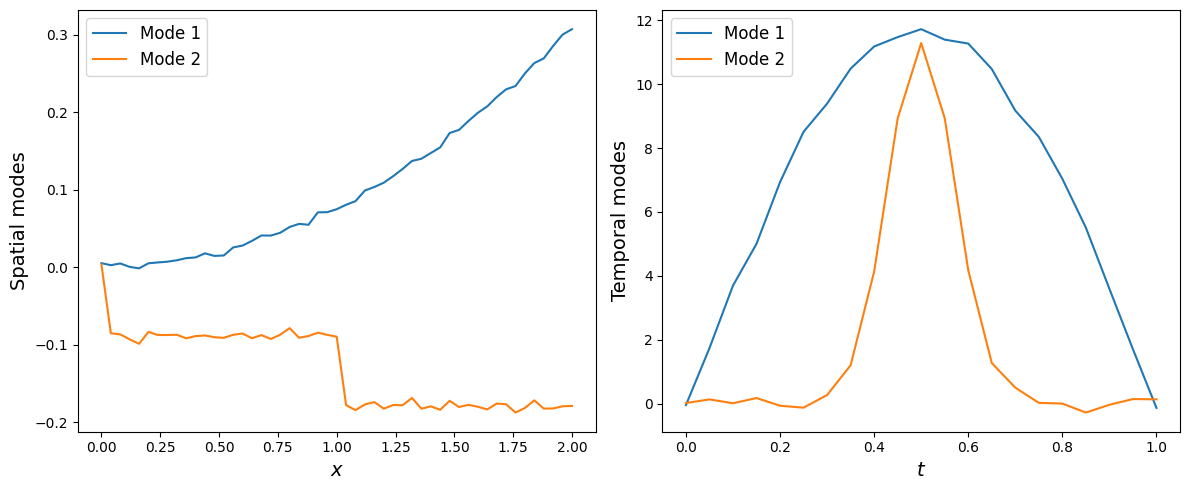

In [37]:
font_size = 14

fig, axis = plt.subplots(1, 2, figsize=(12, 5*1))
axs = axis.flatten()

# Spatial modes
for r in range(R):
    axs[0].plot(x, U_s[:,r], label=f'Mode {r+1}')
axs[0].set_xlabel(r'$x$', fontsize=font_size)
axs[0].set_ylabel('Spatial modes', fontsize=font_size)
axs[0].legend(fontsize=font_size-2, loc='upper left')
# axs[0].set_title('Right Singular Vectors')

# Temporal modes
for r in range(R):
    axs[1].plot(t, U_t[:,r], label=f'Mode {r+1}')
axs[1].set_xlabel(r'$t$', fontsize=font_size)
axs[1].set_ylabel('Temporal modes', fontsize=font_size)
axs[1].legend(fontsize=font_size-2, loc='upper left')

plt.tight_layout()
plt.savefig(f"Results_synthetic/synthetic_ftd_spatial_temporal_modes.pdf", bbox_inches='tight')
plt.show()

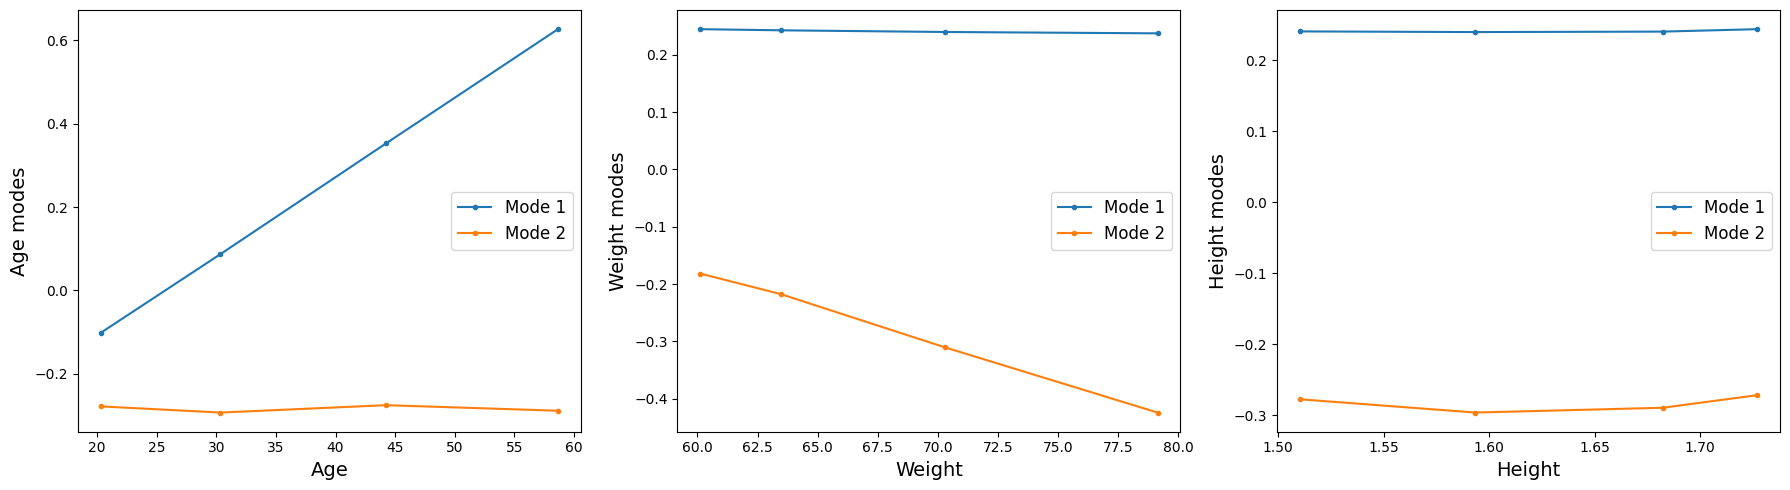

In [38]:
n_rows = math.ceil((Phi.shape[1]/K)/3)
fig, axis = plt.subplots(n_rows, 3, figsize=(6*3, 5*n_rows))
axs = axis.flatten()

# Age modes
for r in range(R):
    axs[0].plot(nodes_dict['age'], C[0:K,r], ".-",label=f'Mode {r+1}')
axs[0].set_xlabel('Age', fontsize=font_size)
# axs[0].set_ylabel(r'$C_{\rm age}$', fontsize=font_size)
axs[0].set_ylabel(r'Age modes', fontsize=font_size)
axs[0].legend(fontsize=font_size-2, loc='center right')

# Weight modes
for r in range(R):
    axs[1].plot(nodes_dict['weight'], C[K:2*K,r], ".-", label=f'Mode {r+1}')
axs[1].set_xlabel('Weight', fontsize=font_size)
# axs[1].set_ylabel(r'$C_{\rm weight}$', fontsize=font_size)
axs[1].set_ylabel(r'Weight modes', fontsize=font_size)
axs[1].legend(fontsize=font_size-2, loc='center right')

# Height modes
for r in range(R):
    axs[2].plot(nodes_dict['height'], C[2*K:3*K,r], ".-", label=f'Mode {r+1}')
axs[2].set_xlabel('Height', fontsize=font_size)
# axs[2].set_ylabel(r'$C_{\rm height}$', fontsize=font_size)
axs[2].set_ylabel(r'Height modes', fontsize=font_size)
axs[2].legend(fontsize=font_size-2, loc='center right')

plt.tight_layout()
plt.savefig(f"Results_synthetic/synthetic_ftd_C_coefficients.pdf", bbox_inches='tight')
plt.show()

### FTD - Predicting fields

In [39]:
random.seed(12345)

n_vol_pred = 5

age_pred    = [20, 60, 20, 60, 40]
weight_pred = [60, 80, 80, 60, 70]
height_pred = [random.uniform(1.5, 1.75) for _ in range(n_vol_pred)]

Phi_age_pred    = P1DesignMatrix(nodes_dict['age']).build(age_pred)
Phi_weight_pred = P1DesignMatrix(nodes_dict['weight']).build(weight_pred)
Phi_height_pred = P1DesignMatrix(nodes_dict['height']).build(height_pred)

Phi_pred = torch.cat([Phi_age_pred, Phi_weight_pred, Phi_height_pred], dim=1).detach().cpu().numpy()

X_pred = np.einsum('sr,tr,pr->stp', U_s, U_t, Phi_pred @ C)

In [40]:
P_real_list = []
for i in range(n_vol_pred):
    P = np.array([((age_pred[i]/np.max(age)) * f_quad(x) * g_sin(t) + weight_pred[i]/np.max(weight) * f_ceil(x) * g_gauss(t)) for t in t])
    P_real_list.append(P)

P_real_3d = np.stack(P_real_list, axis=0)
X_real    = np.transpose(P_real_3d, (2, 1, 0))

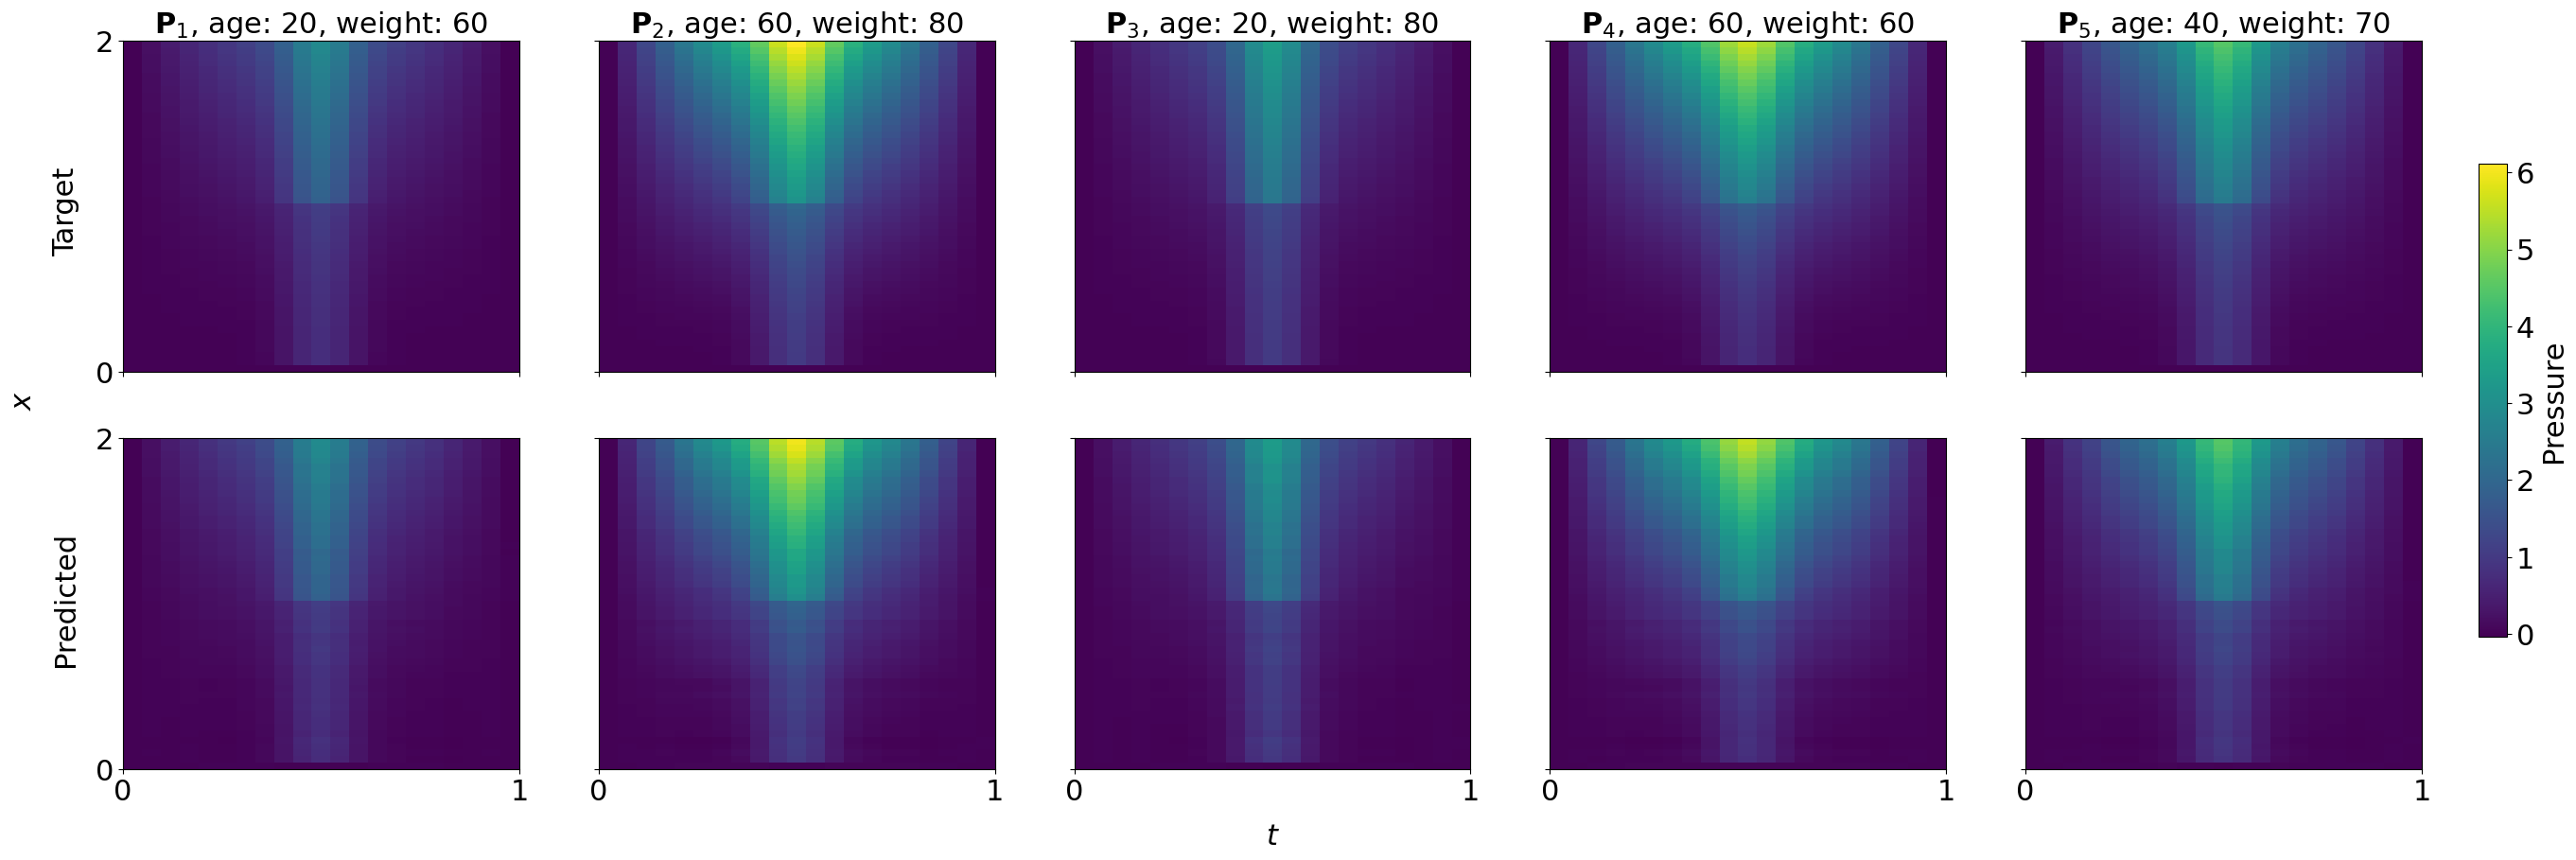

In [41]:
nrows = 2
ncols = math.ceil(2*n_vol_pred / nrows)

vmin = np.min((X_real.flatten(), X_pred.flatten()))
vmax = np.max((X_real.flatten(), X_pred.flatten()))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_vol_pred):
    ## Real fields
    field_2d_real = X_real[:, :, i]
    field_2d_pred = X_pred[:, :, i]
    
    # origin='lower' puts the 0th spatial index at the bottom of the y-axis
    # aspect='auto' stretches the pixels to fit the subplot nicely (since 21 != 51)
    im = axes[i].imshow(
        field_2d_real,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        extent=[np.min(t), np.max(t), np.min(x), np.max(x)]
    )
    
    # axes[i].set_title(f'Vol {i+1} | Grp {groupe[i]}', fontsize=10)
    axes[i].set_title(rf'$\mathbf{{P}}_{{ {i+1} }}$, age: {age_pred[i]}, weight: {weight_pred[i]}', fontsize=22)
    axes[i].xaxis.set_major_locator(LinearLocator(3))
    axes[i].yaxis.set_major_locator(LinearLocator(3))
    axes[i].tick_params(axis='both', which='major', labelsize=22)

    ## Predicted fields
    im = axes[i+ncols].imshow(
        field_2d_pred,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        extent=[np.min(t), np.max(t), np.min(x), np.max(x)]
    )

    # axes[i+ncols].set_title(f'Vol {i+1}', fontsize=14)
    axes[i+ncols].xaxis.set_major_locator(LinearLocator(2))
    axes[i+ncols].yaxis.set_major_locator(LinearLocator(2))
    axes[i+ncols].tick_params(axis='both', which='major', labelsize=22)

for j in range(2*n_vol_pred, len(axes)):
    axes[j].axis('off')

left_margin = 0.07
right_margin = 0.88
# fig.subplots_adjust(right=0.9)
fig.subplots_adjust(left=left_margin, right=right_margin)

# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax = fig.add_axes([0.9, 0.25, 0.01, 0.5]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Pressure', size=22)
cbar.ax.tick_params(labelsize=22)

center_x = (left_margin + right_margin) / 2.0

fig.text(center_x, 0.03, r'$t$', ha='center', fontsize=22)
fig.text(0.03, 0.5, r'$x$', va='center', rotation='vertical', fontsize=22)
fig.text(0.045, 0.7, 'Target', va='center', rotation='vertical', fontsize=22)
fig.text(0.045, 0.29, 'Predicted', va='center', rotation='vertical', fontsize=22)
plt.savefig(f"Results_synthetic/predicted_synthetic_fields.pdf", bbox_inches='tight')
plt.show()